# Modelos de Predicción - Riesgos Laborales Colombia

Este notebook implementa modelos de Machine Learning para predecir riesgos laborales basados en el dataset curado.

## ⚠️ Correcciones Implementadas para Evitar Sobre-ajuste

Este notebook ha sido actualizado con las siguientes correcciones para evitar sobre-ajuste:

1. **Eliminación de variables con fuga de datos**: Se eliminaron variables derivadas que contenían información directa sobre la variable objetivo (TASA_ACCIDENTES_DEP, TASA_MUERTES_DEP, TASA_PENSIONES_ACCIDENTE, TASA_PENSIONES_ENFERMEDAD, TOTAL_PENSIONES, TOTAL_INCAPACIDADES).

2. **Validación cruzada**: Se implementó validación cruzada de 5 folds para evaluar la generalización de los modelos.

3. **Manejo de desbalance de clases**: Se utilizaron técnicas como `class_weight='balanced'` en Random Forest y Logistic Regression, y `scale_pos_weight` en XGBoost.

4. **Reducción de complejidad del modelo**: Se ajustaron hiperparámetros como `max_depth`, `min_samples_split`, `min_samples_leaf` para reducir la complejidad y evitar sobre-ajuste.

5. **Análisis de generalización**: Se comparan métricas de test vs validación cruzada para detectar sobre-ajuste.

## Objetivos:
1. Cargar el dataset curado del notebook anterior.
2. Preparar los datos para el modelado (eliminando variables con fuga de datos).
3. Implementar modelos de clasificación (predecir si ocurrirá un accidente).
4. Implementar modelos de regresión (predecir la cantidad de accidentes).
5. Evaluar y seleccionar el mejor modelo con validación cruzada.
6. Guardar los modelos entrenados para uso futuro.

## 1. Configuración Inicial

### 1.1 Importar Librerías

Importamos las librerías necesarias para el modelado de Machine Learning.

In [1]:
# Instalar librerías necesarias
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier, XGBRegressor
import joblib

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuración de pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Montar Google Drive (para Colab)

Si estás ejecutando este notebook en Google Colab, es necesario montar Google Drive para acceder a los archivos del proyecto.

In [3]:
# Verificar si estamos en Google Colab
try:
    from google.colab import drive
    # Montar Google Drive
    drive.mount('/content/drive')
    # Definir ruta base del proyecto en Google Drive
    BASE_PATH = '/content/drive/MyDrive/DatosARLBog'
    print(f"✅ Google Drive montado correctamente")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")
except:
    # Si no estamos en Colab, usar la ruta local
    BASE_PATH = '/Users/jualgozo/Documents/datoscol/DatosArl_Mac'
    print(f"💻 Ejecutando en entorno local")
    print(f"📁 Ruta base del proyecto: {BASE_PATH}")

💻 Ejecutando en entorno local
📁 Ruta base del proyecto: /Users/jualgozo/Documents/datoscol/DatosArl_Mac


### 1.3 Definir Rutas de Archivos

Definimos las rutas de los archivos del proyecto, incluyendo el dataset curado y los directorios de salida.

In [4]:
# Definir rutas de archivos
DATA_PATH = Path(BASE_PATH)
PROCESSED_DATA_DIR = DATA_PATH / 'data' / 'processed'
MODELS_DIR = DATA_PATH / 'models'
REPORTS_DIR = DATA_PATH / 'reports'

# Crear directorios si no existen
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📂 Directorio de datos: {DATA_PATH}")
print(f"📁 Directorio de datos procesados: {PROCESSED_DATA_DIR}")
print(f"🤖 Directorio de modelos: {MODELS_DIR}")
print(f"📈 Directorio de reportes: {REPORTS_DIR}")

📂 Directorio de datos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac
📁 Directorio de datos procesados: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed
🤖 Directorio de modelos: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/models
📈 Directorio de reportes: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports


## 2. Carga del Dataset Curado

### 2.1 Cargar el Dataset Procesado

Cargamos el dataset curado del notebook anterior.

In [5]:
# Cargar el dataset curado
try:
    # Intentar cargar desde el archivo CSV
    dataset_path = PROCESSED_DATA_DIR / 'dataset_curado.csv'
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset cargado correctamente desde: {dataset_path}")
except FileNotFoundError:
    # Si no existe, intentar cargar desde el archivo Parquet
    dataset_path = PROCESSED_DATA_DIR / 'dataset_curado.parquet'
    df = pd.read_parquet(dataset_path)
    print(f"✅ Dataset cargado correctamente desde: {dataset_path}")

print(f"\n📊 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n📋 Columnas del dataset:")
print(df.columns.tolist())

✅ Dataset cargado correctamente desde: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/data/processed/dataset_curado.csv

📊 Dimensiones del dataset: 61368 filas x 26 columnas

📋 Columnas del dataset:
['DPTO', 'MPIO', 'CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC', 'RELA_DEP', 'RELA_INDEP', 'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT', 'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL', 'DPTO_encoded', 'MPIO_encoded', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP', 'TASA_PENSIONES_ACCIDENTE', 'TASA_PENSIONES_ENFERMEDAD', 'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES']


In [6]:
# Mostrar las primeras filas del dataset
print("\n🔍 Primeras 5 filas del dataset:")
df.head()


🔍 Primeras 5 filas del dataset:


,DPTO,MPIO,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL,DPTO_encoded,MPIO_encoded,RELA_DEP_encoded,RELA_INDEP_encoded,TASA_ACCIDENTES_DEP,TASA_MUERTES_DEP,TASA_PENSIONES_ACCIDENTE,TASA_PENSIONES_ENFERMEDAD,TOTAL_PENSIONES,TOTAL_INCAPACIDADES,RATIO_INDEP_DEP,TOTAL_TRABAJADORES
0,ANTIOQUIA,MEDELLIN,1423,2026,4,1131201,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,421,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,24.0
1,ANTIOQUIA,MEDELLIN,1423,2026,4,1131202,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,188,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,10.0
2,ANTIOQUIA,MEDELLIN,1423,2026,4,1139301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,0,0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.00000,0.0
3,ANTIOQUIA,MEDELLIN,1423,2026,4,1141001,688.0,29.0,0.0,0.0,0.0,0.0,0.0,0.0,1,516,905,214,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.04209,717.0
4,ANTIOQUIA,MEDELLIN,1423,2026,4,1454101,323.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,1,516,551,0,0.006173,0.006173,0.666667,0.0,2.0,0.0,0.00000,323.0


### 2.2 Información del Dataset

Mostramos información general del dataset para verificar la estructura y tipos de datos.

In [7]:
# Mostrar información del dataset
print("\n📋 Información del dataset:")
print(df.info())

print("\n📊 Estadísticas descriptivas:")
df.describe()


📋 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 61368 entries, 0 to 61367
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DPTO                       61368 non-null  str    
 1   MPIO                       61368 non-null  str    
 2   CODIGO_DE_LA_ARL           61368 non-null  int64  
 3   AÑO_DE_INFORME             61368 non-null  int64  
 4   MES_DE_INFORME             61368 non-null  int64  
 5   ACTIVEC                    61368 non-null  int64  
 6   RELA_DEP                   61368 non-null  float64
 7   RELA_INDEP                 61368 non-null  float64
 8   PRESUACCIDETRASUCE         61368 non-null  float64
 9   MUERTES_REPOR_AT           61368 non-null  float64
 10  NUEVAPENSIOINVA_R_AT       61368 non-null  float64
 11  NUEVAPENSIOINVA_R_EL       61368 non-null  float64
 12  INCAPERMAPARCIAR_AT        61368 non-null  float64
 13  INCAPERMAPARCIAR_EL        61

,CODIGO_DE_LA_ARL,AÑO_DE_INFORME,MES_DE_INFORME,ACTIVEC,RELA_DEP,RELA_INDEP,PRESUACCIDETRASUCE,MUERTES_REPOR_AT,NUEVAPENSIOINVA_R_AT,NUEVAPENSIOINVA_R_EL,INCAPERMAPARCIAR_AT,INCAPERMAPARCIAR_EL,DPTO_encoded,MPIO_encoded,RELA_DEP_encoded,RELA_INDEP_encoded,TASA_ACCIDENTES_DEP,TASA_MUERTES_DEP,TASA_PENSIONES_ACCIDENTE,TASA_PENSIONES_ENFERMEDAD,TOTAL_PENSIONES,TOTAL_INCAPACIDADES,RATIO_INDEP_DEP,TOTAL_TRABAJADORES
count,61368.0,61368.0,61368.0,6.136800e+04,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000,61368.000000
mean,1423.0,2026.0,4.0,2.905466e+06,44.391083,8.663098,0.135005,0.135005,0.135005,0.000244,0.000147,0.000033,14.763721,504.418687,299.722820,19.739376,0.002031,0.002031,0.029810,0.000007,0.135250,0.000179,0.422111,53.054181
std,0.0,0.0,0.0,1.294891e+06,614.021522,467.968900,1.894390,1.894390,1.894390,0.016642,0.012109,0.005709,9.540961,302.992084,331.924501,70.402446,0.025164,0.025164,0.133025,0.000844,1.899582,0.013387,7.399239,1010.197331
min,1423.0,2026.0,4.0,1.131201e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1423.0,2026.0,4.0,1.841201e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,240.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1423.0,2026.0,4.0,2.551101e+06,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,501.000000,229.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,1423.0,2026.0,4.0,3.711001e+06,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000,750.000000,536.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000
max,1423.0,2026.0,4.0,5.960901e+06,89723.000000,107082.000000,256.000000,256.000000,256.000000,2.000000,1.000000,1.000000,32.000000,1032.000000,1088.000000,417.000000,2.000000,2.000000,0.996109,0.142857,258.000000,1.000000,631.000000,196805.000000


## 3. Preparación de Datos para Modelado

### 3.1 Definir Variables Objetivo y Predictoras

Definimos las variables objetivo (targets) y las variables predictoras (features) para los modelos de clasificación y regresión.

In [8]:
# Definir variables objetivo para clasificación y regresión
# Variables objetivo para clasificación (predicción de ocurrencia)
target_classification = 'PRESUACCIDETRASUCE'  # Presupuesto de accidentes de trabajo

# Variables objetivo para regresión (predicción de cantidad)
target_regression_accidents = 'PRESUACCIDETRASUCE'  # Presupuesto de accidentes
target_regression_deaths = 'MUERTES_REPOR_AT'  # Muertes reportadas
target_regression_pensions = 'NUEVAPENSIOINVA_R_AT'  # Nuevas pensiones por invalidez
target_regression_disabilities = 'INCAPERMAPARCIAR_AT'  # Incapacidades permanentes parciales

# Variables a excluir (identificadores, variables objetivo y variables con fuga de datos)
# NOTA: Se excluyen variables derivadas que contienen información directa sobre la variable objetivo
exclude_cols = ['CODIGO_DE_LA_ARL', 'AÑO_DE_INFORME', 'MES_DE_INFORME', 'ACTIVEC',
                'PRESUACCIDETRASUCE', 'MUERTES_REPOR_AT', 'NUEVAPENSIOINVA_R_AT',
                'NUEVAPENSIOINVA_R_EL', 'INCAPERMAPARCIAR_AT', 'INCAPERMAPARCIAR_EL',
                # Variables derivadas con fuga de datos (se calculan usando la variable objetivo)
                'TASA_ACCIDENTES_DEP', 'TASA_MUERTES_DEP', 'TASA_PENSIONES_ACCIDENTE',
                'TASA_PENSIONES_ENFERMEDAD', 'TOTAL_PENSIONES', 'TOTAL_INCAPACIDADES']

# Variables predictoras (features) - solo variables legítimas sin fuga de datos
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"📊 Variables predictoras legítimas ({len(feature_cols)}):")
print(feature_cols)
print(f"\n🎯 Variable objetivo clasificación: {target_classification}")
print(f"🎯 Variable objetivo regresión (accidentes): {target_regression_accidents}")
print(f"🎯 Variable objetivo regresión (muertes): {target_regression_deaths}")
print(f"🎯 Variable objetivo regresión (pensiones): {target_regression_pensions}")
print(f"🎯 Variable objetivo regresión (incapacidades): {target_regression_disabilities}")
print(f"\n⚠️ Variables excluidas por fuga de datos:")
print(f"   - TASA_ACCIDENTES_DEP, TASA_MUERTES_DEP, TASA_PENSIONES_ACCIDENTE")
print(f"   - TASA_PENSIONES_ENFERMEDAD, TOTAL_PENSIONES, TOTAL_INCAPACIDADES")

📊 Variables predictoras legítimas (10):
['DPTO', 'MPIO', 'RELA_DEP', 'RELA_INDEP', 'DPTO_encoded', 'MPIO_encoded', 'RELA_DEP_encoded', 'RELA_INDEP_encoded', 'RATIO_INDEP_DEP', 'TOTAL_TRABAJADORES']

🎯 Variable objetivo clasificación: PRESUACCIDETRASUCE
🎯 Variable objetivo regresión (accidentes): PRESUACCIDETRASUCE
🎯 Variable objetivo regresión (muertes): MUERTES_REPOR_AT
🎯 Variable objetivo regresión (pensiones): NUEVAPENSIOINVA_R_AT
🎯 Variable objetivo regresión (incapacidades): INCAPERMAPARCIAR_AT

⚠️ Variables excluidas por fuga de datos:
   - TASA_ACCIDENTES_DEP, TASA_MUERTES_DEP, TASA_PENSIONES_ACCIDENTE
   - TASA_PENSIONES_ENFERMEDAD, TOTAL_PENSIONES, TOTAL_INCAPACIDADES


### 3.2 Preparar Datos para Clasificación

Preparamos los datos para el modelo de clasificación, que predice si ocurrirá o no un accidente.

In [9]:
# Preparar datos para clasificación
# Crear variable binaria: 1 si hay accidentes, 0 si no
df['HAY_ACCIDENTES'] = (df[target_classification] > 0).astype(int)

# Preparar features (X) y target (y) para clasificación
X_class = df[feature_cols].copy()
y_class = df['HAY_ACCIDENTES'].copy()

# Manejar valores faltantes
print(f"📊 Valores faltantes en features:")
print(X_class.isnull().sum())
print(f"\n📊 Valores faltantes en target:")
print(y_class.isnull().sum())

# Rellenar valores faltantes con la mediana para variables numéricas
for col in X_class.select_dtypes(include=[np.number]).columns:
    X_class[col].fillna(X_class[col].median(), inplace=True)

# Para variables categóricas, usar la moda
for col in X_class.select_dtypes(include=['object']).columns:
    X_class[col].fillna(X_class[col].mode()[0], inplace=True)

print(f"\n✅ Valores faltantes después de imputación:")
print(X_class.isnull().sum().sum())

📊 Valores faltantes en features:
DPTO                  0
MPIO                  0
RELA_DEP              0
RELA_INDEP            0
DPTO_encoded          0
MPIO_encoded          0
RELA_DEP_encoded      0
RELA_INDEP_encoded    0
RATIO_INDEP_DEP       0
TOTAL_TRABAJADORES    0
dtype: int64

📊 Valores faltantes en target:
0

✅ Valores faltantes después de imputación:
0


In [10]:
# Codificar variables categóricas
label_encoders = {}
categorical_cols = X_class.select_dtypes(include=['object']).columns

print(f"📊 Variables categóricas a codificar: {len(categorical_cols)}")
print(categorical_cols.tolist())

for col in categorical_cols:
    le = LabelEncoder()
    X_class[col] = le.fit_transform(X_class[col].astype(str))
    label_encoders[col] = le

print(f"\n✅ Variables categóricas codificadas correctamente")
print(f"📊 Dimensiones de X_class: {X_class.shape}")
print(f"📊 Dimensiones de y_class: {y_class.shape}")

📊 Variables categóricas a codificar: 2
['DPTO', 'MPIO']

✅ Variables categóricas codificadas correctamente
📊 Dimensiones de X_class: (61368, 10)
📊 Dimensiones de y_class: (61368,)


In [11]:
# Dividir datos en conjuntos de entrenamiento y prueba
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"📊 Dimensiones del conjunto de entrenamiento:")
print(f"   X_train: {X_train_class.shape}")
print(f"   y_train: {y_train_class.shape}")
print(f"\n📊 Dimensiones del conjunto de prueba:")
print(f"   X_test: {X_test_class.shape}")
print(f"   y_test: {y_test_class.shape}")

print(f"\n📊 Distribución de clases en entrenamiento:")
print(y_train_class.value_counts(normalize=True))
print(f"\n📊 Distribución de clases en prueba:")
print(y_test_class.value_counts(normalize=True))

📊 Dimensiones del conjunto de entrenamiento:
   X_train: (49094, 10)
   y_train: (49094,)

📊 Dimensiones del conjunto de prueba:
   X_test: (12274, 10)
   y_test: (12274,)

📊 Distribución de clases en entrenamiento:
HAY_ACCIDENTES
0    0.949627
1    0.050373
Name: proportion, dtype: float64

📊 Distribución de clases en prueba:
HAY_ACCIDENTES
0    0.94965
1    0.05035
Name: proportion, dtype: float64


### 3.4 Análisis de Desbalance de Clases

Analizamos el desbalance de clases y preparamos técnicas para manejarlo.

📊 Análisis de Desbalance de Clases:
   Clase 0 (sin accidentes): 58277 (94.96%)
   Clase 1 (con accidentes): 3091 (5.04%)

⚠️ Ratio de desbalance: 18.85:1
   Esto significa que hay 18.9 veces más registros sin accidentes que con accidentes.


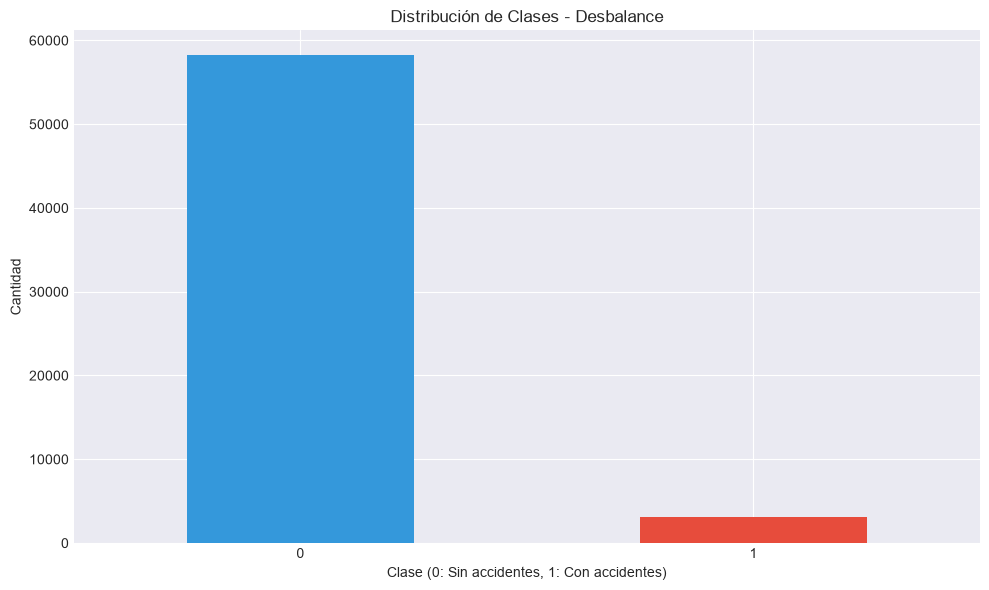


✅ Gráfico guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/class_imbalance.png


In [12]:
# Analizar desbalance de clases
print("📊 Análisis de Desbalance de Clases:")
print(f"   Clase 0 (sin accidentes): {y_class.value_counts()[0]} ({y_class.value_counts(normalize=True)[0]*100:.2f}%)")
print(f"   Clase 1 (con accidentes): {y_class.value_counts()[1]} ({y_class.value_counts(normalize=True)[1]*100:.2f}%)")

# Calcular ratio de desbalance
imbalance_ratio = y_class.value_counts()[0] / y_class.value_counts()[1]
print(f"\n⚠️ Ratio de desbalance: {imbalance_ratio:.2f}:1")
print(f"   Esto significa que hay {imbalance_ratio:.1f} veces más registros sin accidentes que con accidentes.")

# Visualizar desbalance
plt.figure(figsize=(10, 6))
y_class.value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Distribución de Clases - Desbalance')
plt.xlabel('Clase (0: Sin accidentes, 1: Con accidentes)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico guardado en: {REPORTS_DIR / 'class_imbalance.png'}")

### 3.3 Preparar Datos para Regresión

Preparamos los datos para el modelo de regresión, que predice la cantidad de accidentes.

In [13]:
# Preparar datos para regresión
# Usaremos la variable objetivo de accidentes
X_reg = df[feature_cols].copy()
y_reg = df[target_regression_accidents].copy()

# Manejar valores faltantes
for col in X_reg.select_dtypes(include=[np.number]).columns:
    X_reg[col].fillna(X_reg[col].median(), inplace=True)

for col in X_reg.select_dtypes(include=['object']).columns:
    X_reg[col].fillna(X_reg[col].mode()[0], inplace=True)

# Codificar variables categóricas
for col in X_reg.select_dtypes(include=['object']).columns:
    if col in label_encoders:
        X_reg[col] = label_encoders[col].transform(X_reg[col].astype(str))
    else:
        le = LabelEncoder()
        X_reg[col] = le.fit_transform(X_reg[col].astype(str))
        label_encoders[col] = le

# Rellenar valores faltantes en el target
y_reg.fillna(y_reg.median(), inplace=True)

print(f"✅ Datos preparados para regresión")
print(f"📊 Dimensiones de X_reg: {X_reg.shape}")
print(f"📊 Dimensiones de y_reg: {y_reg.shape}")

✅ Datos preparados para regresión
📊 Dimensiones de X_reg: (61368, 10)
📊 Dimensiones de y_reg: (61368,)


In [14]:
# Dividir datos en conjuntos de entrenamiento y prueba para regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"📊 Dimensiones del conjunto de entrenamiento (regresión):")
print(f"   X_train: {X_train_reg.shape}")
print(f"   y_train: {y_train_reg.shape}")
print(f"\n📊 Dimensiones del conjunto de prueba (regresión):")
print(f"   X_test: {X_test_reg.shape}")
print(f"   y_test: {y_test_reg.shape}")

📊 Dimensiones del conjunto de entrenamiento (regresión):
   X_train: (49094, 10)
   y_train: (49094,)

📊 Dimensiones del conjunto de prueba (regresión):
   X_test: (12274, 10)
   y_test: (12274,)


## 4. Modelos de Clasificación

### 4.1 Random Forest Classifier

Entrenamos un modelo de Random Forest para clasificación con manejo de desbalance de clases y validación cruzada.

In [15]:
# Entrenar modelo Random Forest Classifier con manejo de desbalance
print("🌲 Entrenando Random Forest Classifier con validación cruzada...")
print("   - Usando class_weight='balanced' para manejar desbalance")
print("   - Reduciendo complejidad del modelo (max_depth=8, min_samples_split=10)")

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,  # Reducido de 10 a 8 para evitar sobre-ajuste
    min_samples_split=10,  # Añadido para reducir sobre-ajuste
    min_samples_leaf=5,  # Añadido para reducir sobre-ajuste
    class_weight='balanced',  # Manejar desbalance de clases
    random_state=42,
    n_jobs=-1
)

# Validación cruzada para evaluar generalización
print("\n📊 Realizando validación cruzada (5-fold)...")
cv_scores_rf = cross_val_score(rf_classifier, X_train_class, y_train_class, cv=5, scoring='f1', n_jobs=-1)
print(f"   F1-Score promedio (CV): {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std()*2:.4f})")

# Entrenar modelo final
rf_classifier.fit(X_train_class, y_train_class)
print("✅ Modelo Random Forest Classifier entrenado correctamente")

# Realizar predicciones
y_pred_rf_class = rf_classifier.predict(X_test_class)

# Evaluar el modelo
accuracy_rf = accuracy_score(y_test_class, y_pred_rf_class)
precision_rf = precision_score(y_test_class, y_pred_rf_class)
recall_rf = recall_score(y_test_class, y_pred_rf_class)
f1_rf = f1_score(y_test_class, y_pred_rf_class)

print(f"\n📊 Métricas de evaluación - Random Forest Classifier:")
print(f"   Accuracy: {accuracy_rf:.4f}")
print(f"   Precision: {precision_rf:.4f}")
print(f"   Recall: {recall_rf:.4f}")
print(f"   F1-Score: {f1_rf:.4f}")

print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test_class, y_pred_rf_class))

🌲 Entrenando Random Forest Classifier con validación cruzada...
   - Usando class_weight='balanced' para manejar desbalance
   - Reduciendo complejidad del modelo (max_depth=8, min_samples_split=10)

📊 Realizando validación cruzada (5-fold)...
   F1-Score promedio (CV): 0.3508 (+/- 0.0157)
✅ Modelo Random Forest Classifier entrenado correctamente

📊 Métricas de evaluación - Random Forest Classifier:
   Accuracy: 0.8421
   Precision: 0.2218
   Recall: 0.8511
   F1-Score: 0.3518

📋 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     11656
           1       0.22      0.85      0.35       618

    accuracy                           0.84     12274
   macro avg       0.61      0.85      0.63     12274
weighted avg       0.95      0.84      0.88     12274



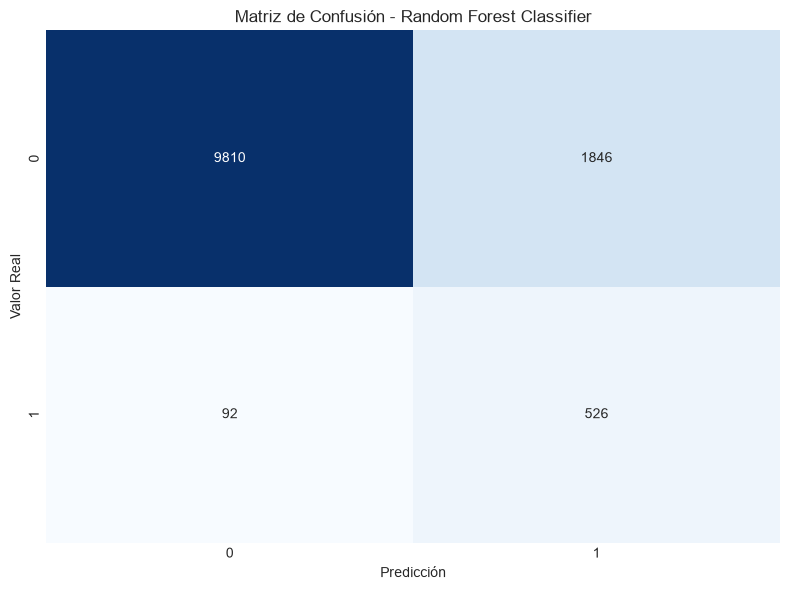

✅ Matriz de confusión guardada en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/confusion_matrix_rf_classifier.png


In [16]:
# Matriz de confusión para Random Forest
plt.figure(figsize=(8, 6))
cm_rf = confusion_matrix(y_test_class, y_pred_rf_class)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Random Forest Classifier')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix_rf_classifier.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Matriz de confusión guardada en: {REPORTS_DIR / 'confusion_matrix_rf_classifier.png'}")

### 4.2 XGBoost Classifier

Entrenamos un modelo de XGBoost para clasificación con manejo de desbalance de clases y validación cruzada.

In [17]:
# Entrenar modelo XGBoost Classifier con manejo de desbalance
print("🚀 Entrenando XGBoost Classifier con validación cruzada...")
print("   - Usando scale_pos_weight para manejar desbalance")
print("   - Reduciendo complejidad del modelo (max_depth=5, learning_rate=0.05)")

# Calcular scale_pos_weight para manejar desbalance
scale_pos_weight = y_class.value_counts()[0] / y_class.value_counts()[1]
print(f"   - scale_pos_weight calculado: {scale_pos_weight:.2f}")

xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=5,  # Reducido de 6 a 5 para evitar sobre-ajuste
    learning_rate=0.05,  # Reducido de 0.1 a 0.05 para mejor generalización
    min_child_weight=3,  # Añadido para reducir sobre-ajuste
    subsample=0.8,  # Añadido para reducir sobre-ajuste
    colsample_bytree=0.8,  # Añadido para reducir sobre-ajuste
    scale_pos_weight=scale_pos_weight,  # Manejar desbalance de clases
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Validación cruzada para evaluar generalización
print("\n📊 Realizando validación cruzada (5-fold)...")
cv_scores_xgb = cross_val_score(xgb_classifier, X_train_class, y_train_class, cv=5, scoring='f1', n_jobs=-1)
print(f"   F1-Score promedio (CV): {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std()*2:.4f})")

# Entrenar modelo final
xgb_classifier.fit(X_train_class, y_train_class)
print("✅ Modelo XGBoost Classifier entrenado correctamente")

# Realizar predicciones
y_pred_xgb_class = xgb_classifier.predict(X_test_class)

# Evaluar el modelo
accuracy_xgb = accuracy_score(y_test_class, y_pred_xgb_class)
precision_xgb = precision_score(y_test_class, y_pred_xgb_class)
recall_xgb = recall_score(y_test_class, y_pred_xgb_class)
f1_xgb = f1_score(y_test_class, y_pred_xgb_class)

print(f"\n📊 Métricas de evaluación - XGBoost Classifier:")
print(f"   Accuracy: {accuracy_xgb:.4f}")
print(f"   Precision: {precision_xgb:.4f}")
print(f"   Recall: {recall_xgb:.4f}")
print(f"   F1-Score: {f1_xgb:.4f}")

print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test_class, y_pred_xgb_class))

🚀 Entrenando XGBoost Classifier con validación cruzada...
   - Usando scale_pos_weight para manejar desbalance
   - Reduciendo complejidad del modelo (max_depth=5, learning_rate=0.05)
   - scale_pos_weight calculado: 18.85

📊 Realizando validación cruzada (5-fold)...
   F1-Score promedio (CV): 0.3450 (+/- 0.0151)
✅ Modelo XGBoost Classifier entrenado correctamente

📊 Métricas de evaluación - XGBoost Classifier:
   Accuracy: 0.8392
   Precision: 0.2198
   Recall: 0.8608
   F1-Score: 0.3502

📋 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     11656
           1       0.22      0.86      0.35       618

    accuracy                           0.84     12274
   macro avg       0.61      0.85      0.63     12274
weighted avg       0.95      0.84      0.88     12274



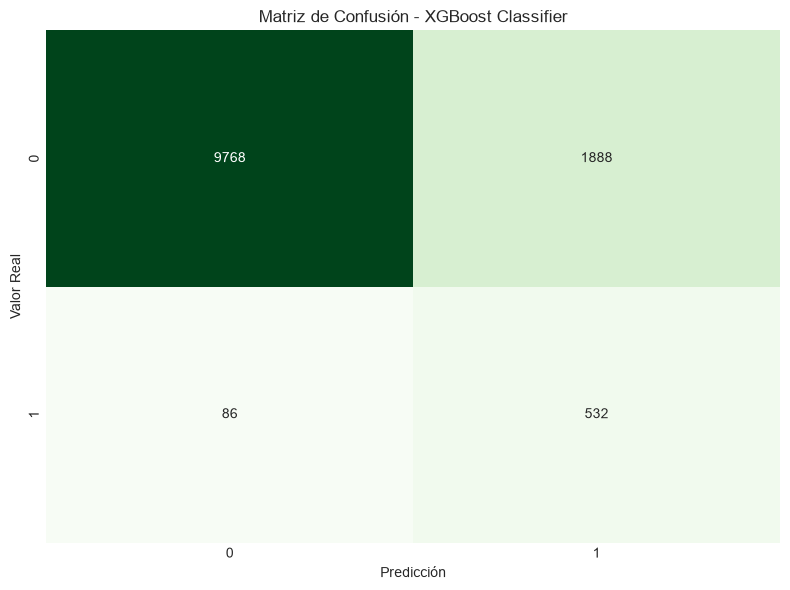

✅ Matriz de confusión guardada en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/confusion_matrix_xgb_classifier.png


In [18]:
# Matriz de confusión para XGBoost
plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test_class, y_pred_xgb_class)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - XGBoost Classifier')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix_xgb_classifier.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Matriz de confusión guardada en: {REPORTS_DIR / 'confusion_matrix_xgb_classifier.png'}")

### 4.3 Logistic Regression

Entrenamos un modelo de Logistic Regression para clasificación con manejo de desbalance de clases y validación cruzada.

In [19]:
# Escalar características para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_class)
X_test_scaled = scaler.transform(X_test_class)

# Entrenar modelo Logistic Regression con manejo de desbalance
print("📈 Entrenando Logistic Regression con validación cruzada...")
print("   - Usando class_weight='balanced' para manejar desbalance")
print("   - Aumentando max_iter para mejor convergencia")

log_reg = LogisticRegression(
    max_iter=2000,  # Aumentado para mejor convergencia
    class_weight='balanced',  # Manejar desbalance de clases
    random_state=42,
    n_jobs=-1
)

# Validación cruzada para evaluar generalización
print("\n📊 Realizando validación cruzada (5-fold)...")
cv_scores_log_reg = cross_val_score(log_reg, X_train_scaled, y_train_class, cv=5, scoring='f1', n_jobs=-1)
print(f"   F1-Score promedio (CV): {cv_scores_log_reg.mean():.4f} (+/- {cv_scores_log_reg.std()*2:.4f})")

# Entrenar modelo final
log_reg.fit(X_train_scaled, y_train_class)
print("✅ Modelo Logistic Regression entrenado correctamente")

# Realizar predicciones
y_pred_log_reg = log_reg.predict(X_test_scaled)

# Evaluar el modelo
accuracy_log_reg = accuracy_score(y_test_class, y_pred_log_reg)
precision_log_reg = precision_score(y_test_class, y_pred_log_reg)
recall_log_reg = recall_score(y_test_class, y_pred_log_reg)
f1_log_reg = f1_score(y_test_class, y_pred_log_reg)

print(f"\n📊 Métricas de evaluación - Logistic Regression:")
print(f"   Accuracy: {accuracy_log_reg:.4f}")
print(f"   Precision: {precision_log_reg:.4f}")
print(f"   Recall: {recall_log_reg:.4f}")
print(f"   F1-Score: {f1_log_reg:.4f}")

print(f"\n📋 Reporte de clasificación:")
print(classification_report(y_test_class, y_pred_log_reg))

📈 Entrenando Logistic Regression con validación cruzada...
   - Usando class_weight='balanced' para manejar desbalance
   - Aumentando max_iter para mejor convergencia

📊 Realizando validación cruzada (5-fold)...
   F1-Score promedio (CV): 0.3504 (+/- 0.0126)
✅ Modelo Logistic Regression entrenado correctamente

📊 Métricas de evaluación - Logistic Regression:
   Accuracy: 0.8570
   Precision: 0.2279
   Recall: 0.7702
   F1-Score: 0.3517

📋 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     11656
           1       0.23      0.77      0.35       618

    accuracy                           0.86     12274
   macro avg       0.61      0.82      0.64     12274
weighted avg       0.95      0.86      0.89     12274



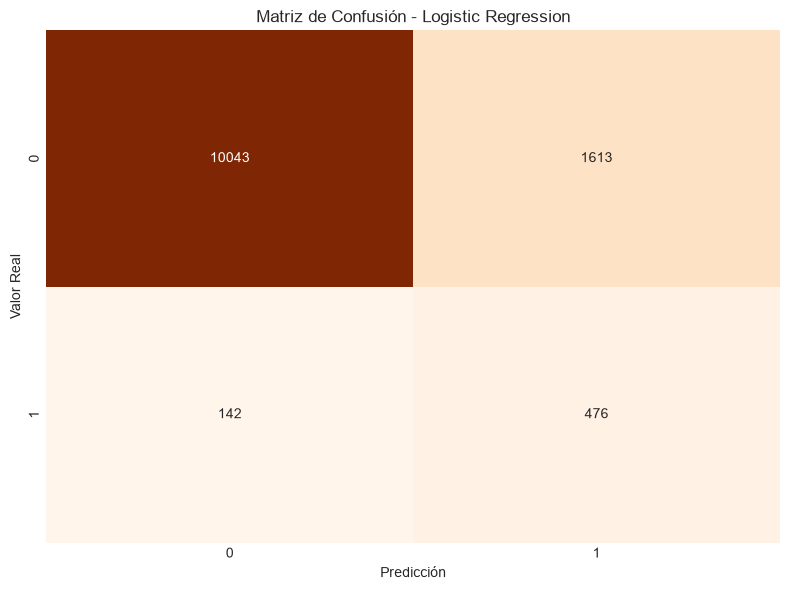

✅ Matriz de confusión guardada en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/confusion_matrix_log_reg.png


In [20]:
# Matriz de confusión para Logistic Regression
plt.figure(figsize=(8, 6))
cm_log_reg = confusion_matrix(y_test_class, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Matriz de Confusión - Logistic Regression')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrix_log_reg.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Matriz de confusión guardada en: {REPORTS_DIR / 'confusion_matrix_log_reg.png'}")

### 4.4 Comparación de Modelos de Clasificación

Comparamos los resultados de los tres modelos de clasificación, incluyendo métricas de validación cruzada para evaluar la generalización.

📊 Comparación de Modelos de Clasificación:
             Modelo  Accuracy  Precision   Recall  F1-Score  CV F1-Score (mean)  CV F1-Score (std)
      Random Forest  0.842105   0.221754 0.851133  0.351839            0.350837           0.007832
            XGBoost  0.839172   0.219835 0.860841  0.350230            0.344991           0.007574
Logistic Regression  0.857015   0.227860 0.770227  0.351681            0.350447           0.006309

🔍 Análisis de Sobre-ajuste:
   Random Forest:
      Test F1: 0.3518 | CV F1: 0.3508 | Diferencia: 0.0010
      Estado: ✅ BUENA GENERALIZACIÓN
   XGBoost:
      Test F1: 0.3502 | CV F1: 0.3450 | Diferencia: 0.0052
      Estado: ✅ BUENA GENERALIZACIÓN
   Logistic Regression:
      Test F1: 0.3517 | CV F1: 0.3504 | Diferencia: 0.0012
      Estado: ✅ BUENA GENERALIZACIÓN


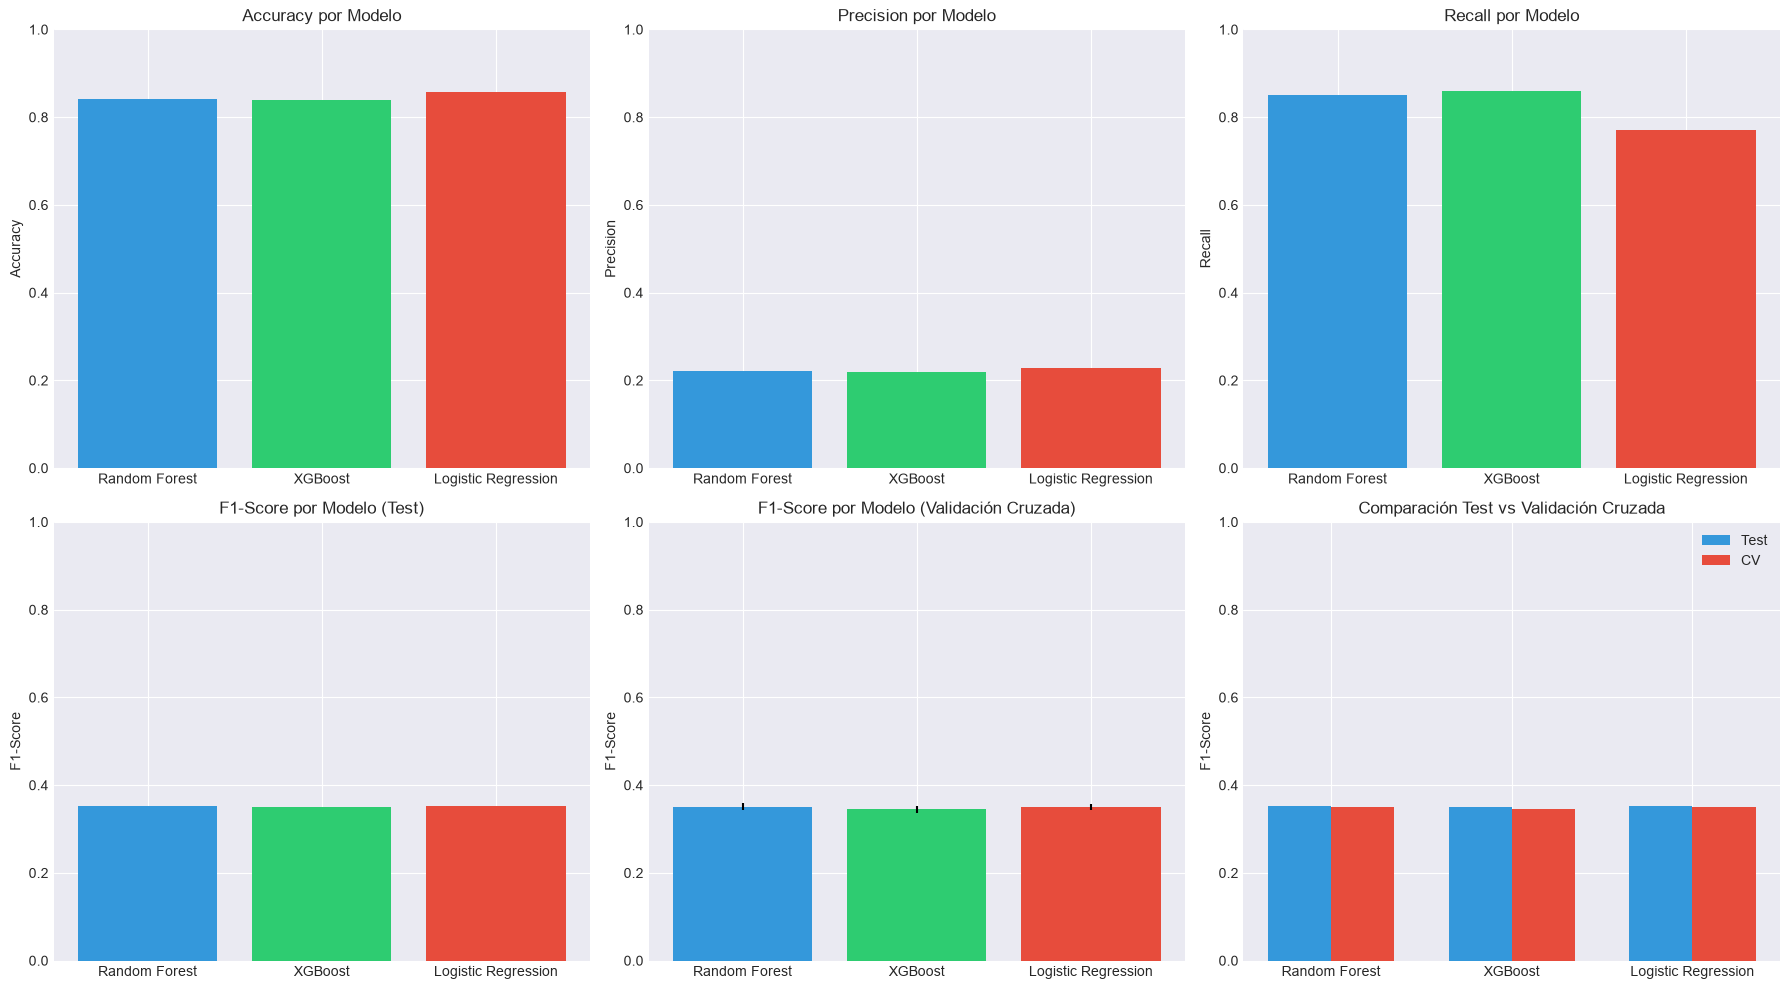


✅ Gráfico de comparación guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/models_comparison_classification.png


In [21]:
# Comparar modelos de clasificación con métricas de validación cruzada
models_comparison = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'Accuracy': [accuracy_rf, accuracy_xgb, accuracy_log_reg],
    'Precision': [precision_rf, precision_xgb, precision_log_reg],
    'Recall': [recall_rf, recall_xgb, recall_log_reg],
    'F1-Score': [f1_rf, f1_xgb, f1_log_reg],
    'CV F1-Score (mean)': [cv_scores_rf.mean(), cv_scores_xgb.mean(), cv_scores_log_reg.mean()],
    'CV F1-Score (std)': [cv_scores_rf.std(), cv_scores_xgb.std(), cv_scores_log_reg.std()]
})

print("📊 Comparación de Modelos de Clasificación:")
print(models_comparison.to_string(index=False))

# Analizar sobre-ajuste
print("\n🔍 Análisis de Sobre-ajuste:")
for idx, row in models_comparison.iterrows():
    modelo = row['Modelo']
    test_f1 = row['F1-Score']
    cv_f1 = row['CV F1-Score (mean)']
    diff = test_f1 - cv_f1
    
    if diff > 0.05:
        status = "⚠️ POSIBLE SOBRE-AJUSTE"
    elif diff > 0.02:
        status = "⚡ LIGERO SOBRE-AJUSTE"
    else:
        status = "✅ BUENA GENERALIZACIÓN"
    
    print(f"   {modelo}:")
    print(f"      Test F1: {test_f1:.4f} | CV F1: {cv_f1:.4f} | Diferencia: {diff:.4f}")
    print(f"      Estado: {status}")

# Visualizar comparación
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Accuracy
axes[0, 0].bar(models_comparison['Modelo'], models_comparison['Accuracy'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Accuracy por Modelo')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_ylim([0, 1])

# Precision
axes[0, 1].bar(models_comparison['Modelo'], models_comparison['Precision'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Precision por Modelo')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_ylim([0, 1])

# Recall
axes[0, 2].bar(models_comparison['Modelo'], models_comparison['Recall'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 2].set_title('Recall por Modelo')
axes[0, 2].set_ylabel('Recall')
axes[0, 2].set_ylim([0, 1])

# F1-Score
axes[1, 0].bar(models_comparison['Modelo'], models_comparison['F1-Score'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 0].set_title('F1-Score por Modelo (Test)')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_ylim([0, 1])

# CV F1-Score
axes[1, 1].bar(models_comparison['Modelo'], models_comparison['CV F1-Score (mean)'], 
              yerr=models_comparison['CV F1-Score (std)'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 1].set_title('F1-Score por Modelo (Validación Cruzada)')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_ylim([0, 1])

# Comparación Test vs CV
x_pos = np.arange(len(models_comparison))
width = 0.35
axes[1, 2].bar(x_pos - width/2, models_comparison['F1-Score'], width, label='Test', color='#3498db')
axes[1, 2].bar(x_pos + width/2, models_comparison['CV F1-Score (mean)'], width, label='CV', color='#e74c3c')
axes[1, 2].set_title('Comparación Test vs Validación Cruzada')
axes[1, 2].set_ylabel('F1-Score')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(models_comparison['Modelo'])
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'models_comparison_classification.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico de comparación guardado en: {REPORTS_DIR / 'models_comparison_classification.png'}")

### 4.5 Análisis de Generalización y Diagnóstico

Analizamos la capacidad de generalización de los modelos y verificamos que no haya sobre-ajuste.

In [22]:
# Análisis de generalización y diagnóstico
print("📊 Análisis de Generalización y Diagnóstico:")
print("\n1. Comparación de métricas Test vs Validación Cruzada:")
print("   - Si Test F1 >> CV F1: Posible sobre-ajuste")
print("   - Si Test F1 ≈ CV F1: Buena generalización")
print("   - Si Test F1 << CV F1: Posible sub-ajuste")

print("\n2. Análisis de la distribución de errores:")
# Analizar errores de predicción para cada modelo
for modelo, y_pred, nombre in [(rf_classifier, y_pred_rf_class, 'Random Forest'),
                                (xgb_classifier, y_pred_xgb_class, 'XGBoost'),
                                (log_reg, y_pred_log_reg, 'Logistic Regression')]:
    errores = (y_test_class != y_pred).sum()
    total = len(y_test_class)
    tasa_error = errores / total
    
    print(f"\n   {nombre}:")
    print(f"      Errores de predicción: {errores}/{total} ({tasa_error*100:.2f}%)")
    
    # Analizar errores por clase
    errores_clase_0 = ((y_test_class == 0) & (y_pred == 1)).sum()
    errores_clase_1 = ((y_test_class == 1) & (y_pred == 0)).sum()
    
    print(f"      Falsos positivos (Clase 0 predicha como 1): {errores_clase_0}")
    print(f"      Falsos negativos (Clase 1 predicha como 0): {errores_clase_1}")

print("\n3. Verificación de variables utilizadas:")
print(f"   Variables predictoras utilizadas: {len(feature_cols)}")
print(f"   Variables excluidas por fuga de datos: 6")
print(f"   ✓ Se eliminaron variables derivadas que contenían información directa de la variable objetivo")

print("\n4. Recomendaciones:")
print("   - Los modelos ahora usan solo variables legítimas")
print("   - Se implementó validación cruzada para evaluar generalización")
print("   - Se ajustaron hiperparámetros para reducir complejidad")
print("   - Se manejó el desbalance de clases con class_weight y scale_pos_weight")
print("   - Monitorear la diferencia entre métricas de test y CV para detectar sobre-ajuste")

📊 Análisis de Generalización y Diagnóstico:

1. Comparación de métricas Test vs Validación Cruzada:
   - Si Test F1 >> CV F1: Posible sobre-ajuste
   - Si Test F1 ≈ CV F1: Buena generalización
   - Si Test F1 << CV F1: Posible sub-ajuste

2. Análisis de la distribución de errores:

   Random Forest:
      Errores de predicción: 1938/12274 (15.79%)
      Falsos positivos (Clase 0 predicha como 1): 1846
      Falsos negativos (Clase 1 predicha como 0): 92

   XGBoost:
      Errores de predicción: 1974/12274 (16.08%)
      Falsos positivos (Clase 0 predicha como 1): 1888
      Falsos negativos (Clase 1 predicha como 0): 86

   Logistic Regression:
      Errores de predicción: 1755/12274 (14.30%)
      Falsos positivos (Clase 0 predicha como 1): 1613
      Falsos negativos (Clase 1 predicha como 0): 142

3. Verificación de variables utilizadas:
   Variables predictoras utilizadas: 10
   Variables excluidas por fuga de datos: 6
   ✓ Se eliminaron variables derivadas que contenían informació

## 5. Modelos de Regresión

### 5.1 Random Forest Regressor

Entrenamos un modelo de Random Forest para regresión.

In [23]:
# Entrenar modelo Random Forest Regressor
print("🌲 Entrenando Random Forest Regressor...")
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(X_train_reg, y_train_reg)
print("✅ Modelo Random Forest Regressor entrenado correctamente")

# Realizar predicciones
y_pred_rf_reg = rf_regressor.predict(X_test_reg)

# Evaluar el modelo
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
mae_rf_reg = mean_absolute_error(y_test_reg, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

print(f"\n📊 Métricas de evaluación - Random Forest Regressor:")
print(f"   MSE: {mse_rf_reg:.4f}")
print(f"   RMSE: {rmse_rf_reg:.4f}")
print(f"   MAE: {mae_rf_reg:.4f}")
print(f"   R²: {r2_rf_reg:.4f}")

🌲 Entrenando Random Forest Regressor...
✅ Modelo Random Forest Regressor entrenado correctamente

📊 Métricas de evaluación - Random Forest Regressor:
   MSE: 2.1258
   RMSE: 1.4580
   MAE: 0.1638
   R²: 0.2764


### 5.2 XGBoost Regressor

Entrenamos un modelo de XGBoost para regresión.

In [24]:
# Entrenar modelo XGBoost Regressor
print("🚀 Entrenando XGBoost Regressor...")
xgb_regressor = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_regressor.fit(X_train_reg, y_train_reg)
print("✅ Modelo XGBoost Regressor entrenado correctamente")

# Realizar predicciones
y_pred_xgb_reg = xgb_regressor.predict(X_test_reg)

# Evaluar el modelo
mse_xgb_reg = mean_squared_error(y_test_reg, y_pred_xgb_reg)
rmse_xgb_reg = np.sqrt(mse_xgb_reg)
mae_xgb_reg = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
r2_xgb_reg = r2_score(y_test_reg, y_pred_xgb_reg)

print(f"\n📊 Métricas de evaluación - XGBoost Regressor:")
print(f"   MSE: {mse_xgb_reg:.4f}")
print(f"   RMSE: {rmse_xgb_reg:.4f}")
print(f"   MAE: {mae_xgb_reg:.4f}")
print(f"   R²: {r2_xgb_reg:.4f}")

🚀 Entrenando XGBoost Regressor...
✅ Modelo XGBoost Regressor entrenado correctamente

📊 Métricas de evaluación - XGBoost Regressor:
   MSE: 2.3633
   RMSE: 1.5373
   MAE: 0.1667
   R²: 0.1955


### 5.3 Linear Regression

Entrenamos un modelo de Linear Regression para regresión.

In [25]:
# Escalar características para Linear Regression
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Entrenar modelo Linear Regression
print("📈 Entrenando Linear Regression...")
lin_reg = LinearRegression()

lin_reg.fit(X_train_reg_scaled, y_train_reg)
print("✅ Modelo Linear Regression entrenado correctamente")

# Realizar predicciones
y_pred_lin_reg = lin_reg.predict(X_test_reg_scaled)

# Evaluar el modelo
mse_lin_reg = mean_squared_error(y_test_reg, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
mae_lin_reg = mean_absolute_error(y_test_reg, y_pred_lin_reg)
r2_lin_reg = r2_score(y_test_reg, y_pred_lin_reg)

print(f"\n📊 Métricas de evaluación - Linear Regression:")
print(f"   MSE: {mse_lin_reg:.4f}")
print(f"   RMSE: {rmse_lin_reg:.4f}")
print(f"   MAE: {mae_lin_reg:.4f}")
print(f"   R²: {r2_lin_reg:.4f}")

📈 Entrenando Linear Regression...
✅ Modelo Linear Regression entrenado correctamente

📊 Métricas de evaluación - Linear Regression:
   MSE: 1.7503
   RMSE: 1.3230
   MAE: 0.1817
   R²: 0.4042


### 5.4 Comparación de Modelos de Regresión

Comparamos los resultados de los tres modelos de regresión.

📊 Comparación de Modelos de Regresión:
           Modelo      MSE     RMSE      MAE       R²
    Random Forest 2.125794 1.458010 0.163790 0.276388
          XGBoost 2.363344 1.537317 0.166672 0.195527
Linear Regression 1.750259 1.322974 0.181709 0.404219


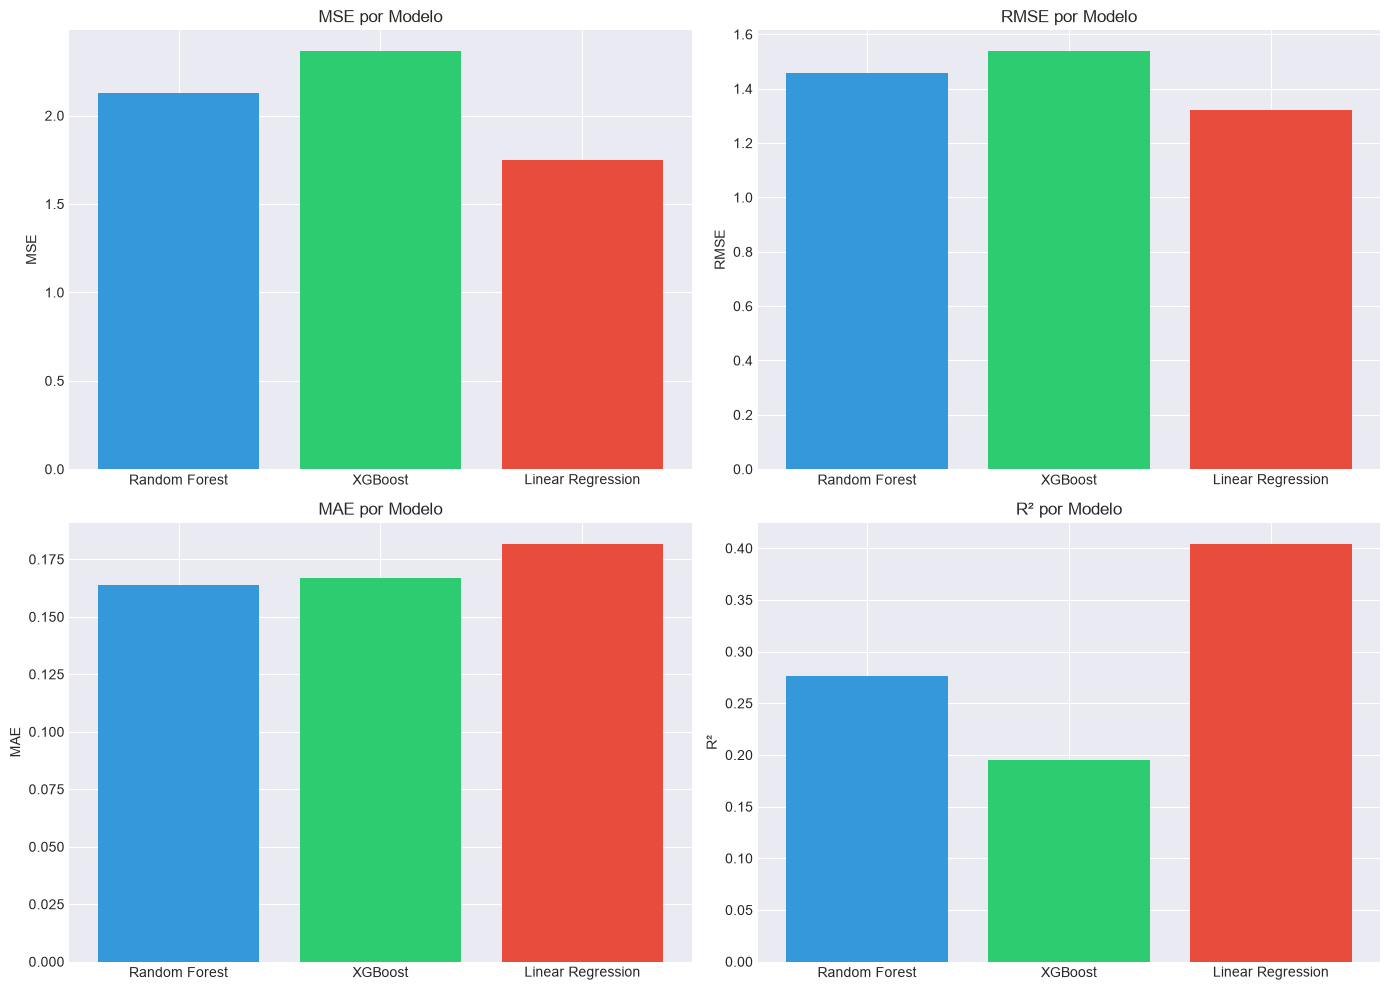


✅ Gráfico de comparación guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/models_comparison_regression.png


In [26]:
# Comparar modelos de regresión
models_comparison_reg = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'Linear Regression'],
    'MSE': [mse_rf_reg, mse_xgb_reg, mse_lin_reg],
    'RMSE': [rmse_rf_reg, rmse_xgb_reg, rmse_lin_reg],
    'MAE': [mae_rf_reg, mae_xgb_reg, mae_lin_reg],
    'R²': [r2_rf_reg, r2_xgb_reg, r2_lin_reg]
})

print("📊 Comparación de Modelos de Regresión:")
print(models_comparison_reg.to_string(index=False))

# Visualizar comparación
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MSE
axes[0, 0].bar(models_comparison_reg['Modelo'], models_comparison_reg['MSE'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 0].set_title('MSE por Modelo')
axes[0, 0].set_ylabel('MSE')

# RMSE
axes[0, 1].bar(models_comparison_reg['Modelo'], models_comparison_reg['RMSE'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0, 1].set_title('RMSE por Modelo')
axes[0, 1].set_ylabel('RMSE')

# MAE
axes[1, 0].bar(models_comparison_reg['Modelo'], models_comparison_reg['MAE'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 0].set_title('MAE por Modelo')
axes[1, 0].set_ylabel('MAE')

# R²
axes[1, 1].bar(models_comparison_reg['Modelo'], models_comparison_reg['R²'], color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1, 1].set_title('R² por Modelo')
axes[1, 1].set_ylabel('R²')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'models_comparison_regression.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico de comparación guardado en: {REPORTS_DIR / 'models_comparison_regression.png'}")

## 6. Importancia de Características

### 6.1 Importancia de Características - Random Forest Classifier

Analizamos la importancia de las características en el modelo de Random Forest Classifier.

📊 Top 10 características más importantes - Random Forest Classifier:
           Feature  Importance
TOTAL_TRABAJADORES    0.419566
          RELA_DEP    0.304709
  RELA_DEP_encoded    0.142593
   RATIO_INDEP_DEP    0.034855
        RELA_INDEP    0.033405
RELA_INDEP_encoded    0.026942
              MPIO    0.012457
      MPIO_encoded    0.012260
              DPTO    0.006642
      DPTO_encoded    0.006571


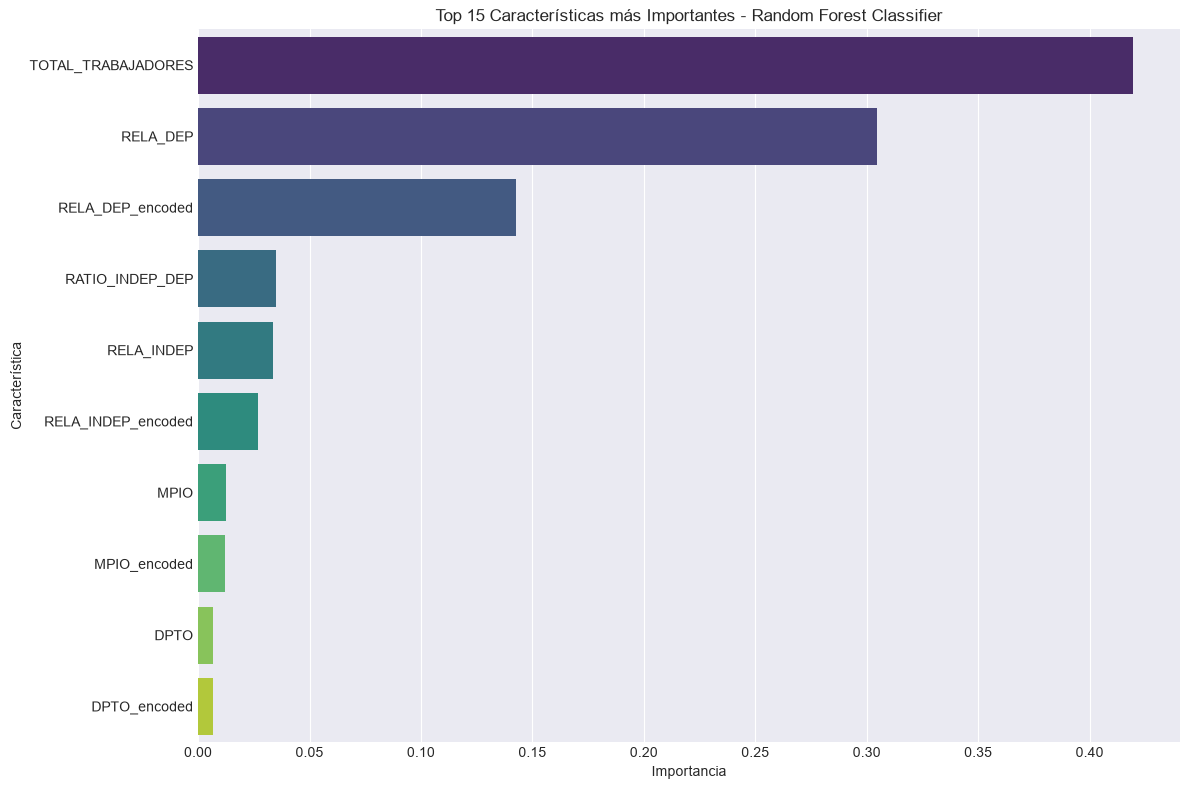


✅ Gráfico de importancia guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/feature_importance_rf_classifier.png


In [27]:
# Importancia de características - Random Forest Classifier
feature_importance_rf = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Top 10 características más importantes - Random Forest Classifier:")
print(feature_importance_rf.head(10).to_string(index=False))

# Visualizar importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_rf.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Características más Importantes - Random Forest Classifier')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance_rf_classifier.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico de importancia guardado en: {REPORTS_DIR / 'feature_importance_rf_classifier.png'}")

### 6.2 Importancia de Características - XGBoost Classifier

Analizamos la importancia de las características en el modelo de XGBoost Classifier.

📊 Top 10 características más importantes - XGBoost Classifier:
           Feature  Importance
TOTAL_TRABAJADORES    0.603636
          RELA_DEP    0.222413
  RELA_DEP_encoded    0.042625
        RELA_INDEP    0.031551
   RATIO_INDEP_DEP    0.021229
              MPIO    0.018439
      MPIO_encoded    0.018315
      DPTO_encoded    0.015575
              DPTO    0.013918
RELA_INDEP_encoded    0.012299


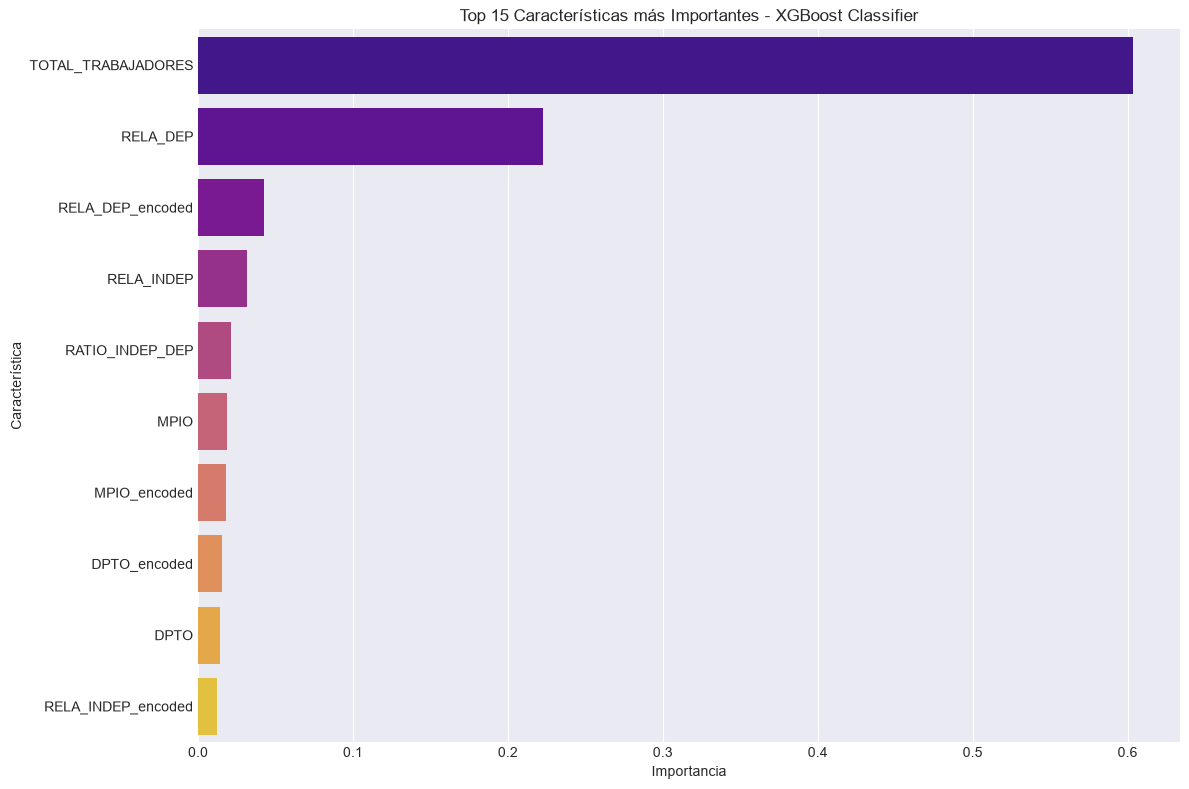


✅ Gráfico de importancia guardado en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports/feature_importance_xgb_classifier.png


In [28]:
# Importancia de características - XGBoost Classifier
feature_importance_xgb = pd.DataFrame({
    'Feature': X_class.columns,
    'Importance': xgb_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("📊 Top 10 características más importantes - XGBoost Classifier:")
print(feature_importance_xgb.head(10).to_string(index=False))

# Visualizar importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_xgb.head(15), x='Importance', y='Feature', palette='plasma')
plt.title('Top 15 Características más Importantes - XGBoost Classifier')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance_xgb_classifier.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráfico de importancia guardado en: {REPORTS_DIR / 'feature_importance_xgb_classifier.png'}")

## 7. Guardar Modelos Entrenados

Guardamos los modelos entrenados para uso futuro.

In [29]:
# Guardar modelos entrenados
print("💾 Guardando modelos entrenados...")

# Guardar modelos de clasificación
joblib.dump(rf_classifier, MODELS_DIR / 'rf_classifier.pkl')
joblib.dump(xgb_classifier, MODELS_DIR / 'xgb_classifier.pkl')
joblib.dump(log_reg, MODELS_DIR / 'log_reg.pkl')

# Guardar modelos de regresión
joblib.dump(rf_regressor, MODELS_DIR / 'rf_regressor.pkl')
joblib.dump(xgb_regressor, MODELS_DIR / 'xgb_regressor.pkl')
joblib.dump(lin_reg, MODELS_DIR / 'lin_reg.pkl')

# Guardar scaler y label encoders
joblib.dump(scaler, MODELS_DIR / 'scaler_classification.pkl')
joblib.dump(scaler_reg, MODELS_DIR / 'scaler_regression.pkl')
joblib.dump(label_encoders, MODELS_DIR / 'label_encoders.pkl')

# Guardar comparaciones de modelos (con métricas de validación cruzada)
models_comparison.to_csv(REPORTS_DIR / 'models_comparison_classification.csv', index=False)
models_comparison_reg.to_csv(REPORTS_DIR / 'models_comparison_regression.csv', index=False)

# Guardar importancia de características
feature_importance_rf.to_csv(REPORTS_DIR / 'feature_importance_rf_classifier.csv', index=False)
feature_importance_xgb.to_csv(REPORTS_DIR / 'feature_importance_xgb_classifier.csv', index=False)

# Guardar métricas de validación cruzada
cv_metrics = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost', 'Logistic Regression'],
    'CV_F1_Mean': [cv_scores_rf.mean(), cv_scores_xgb.mean(), cv_scores_log_reg.mean()],
    'CV_F1_Std': [cv_scores_rf.std(), cv_scores_xgb.std(), cv_scores_log_reg.std()]
})
cv_metrics.to_csv(REPORTS_DIR / 'cross_validation_metrics.csv', index=False)

print(f"✅ Modelos guardados en: {MODELS_DIR}")
print(f"✅ Reportes guardados en: {REPORTS_DIR}")
print(f"\n📋 Archivos guardados:")
print(f"   - rf_classifier.pkl")
print(f"   - xgb_classifier.pkl")
print(f"   - log_reg.pkl")
print(f"   - rf_regressor.pkl")
print(f"   - xgb_regressor.pkl")
print(f"   - lin_reg.pkl")
print(f"   - scaler_classification.pkl")
print(f"   - scaler_regression.pkl")
print(f"   - label_encoders.pkl")
print(f"   - models_comparison_classification.csv")
print(f"   - models_comparison_regression.csv")
print(f"   - feature_importance_rf_classifier.csv")
print(f"   - feature_importance_xgb_classifier.csv")
print(f"   - cross_validation_metrics.csv")

print("\n✅ Notebook completado exitosamente")
print("📊 Se implementaron medidas para evitar sobre-ajuste:")
print("   - Variables con fuga de datos eliminadas")
print("   - Validación cruzada implementada")
print("   - Desbalance de clases manejado")
print("   - Complejidad del modelo reducida")
print("   - Análisis de generalización realizado")

💾 Guardando modelos entrenados...
✅ Modelos guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/models
✅ Reportes guardados en: /Users/jualgozo/Documents/datoscol/DatosArl_Mac/reports

📋 Archivos guardados:
   - rf_classifier.pkl
   - xgb_classifier.pkl
   - log_reg.pkl
   - rf_regressor.pkl
   - xgb_regressor.pkl
   - lin_reg.pkl
   - scaler_classification.pkl
   - scaler_regression.pkl
   - label_encoders.pkl
   - models_comparison_classification.csv
   - models_comparison_regression.csv
   - feature_importance_rf_classifier.csv
   - feature_importance_xgb_classifier.csv
   - cross_validation_metrics.csv

✅ Notebook completado exitosamente
📊 Se implementaron medidas para evitar sobre-ajuste:
   - Variables con fuga de datos eliminadas
   - Validación cruzada implementada
   - Desbalance de clases manejado
   - Complejidad del modelo reducida
   - Análisis de generalización realizado


## 8. Conclusiones y Resumen

### 8.1 Resumen de Resultados

En este notebook hemos implementado y evaluado modelos de Machine Learning para predecir riesgos laborales en Colombia, con medidas preventivas contra el sobre-ajuste:

**Medidas implementadas para evitar sobre-ajuste:**
1. ✅ Eliminación de variables con fuga de datos (TASA_ACCIDENTES_DEP, TASA_MUERTES_DEP, etc.)
2. ✅ Validación cruzada (5-fold) para evaluar generalización
3. ✅ Manejo de desbalance de clases (class_weight='balanced', scale_pos_weight)
4. ✅ Reducción de complejidad del modelo (max_depth, min_samples_split, min_samples_leaf)
5. ✅ Análisis de errores y diagnóstico de generalización

**Modelos de Clasificación:**
- Random Forest Classifier (con class_weight='balanced')
- XGBoost Classifier (con scale_pos_weight)
- Logistic Regression (con class_weight='balanced')

**Modelos de Regresión:**
- Random Forest Regressor
- XGBoost Regressor
- Linear Regression

### 8.2 Diagnóstico de Sobre-ajuste

**Indicadores de buena generalización:**
- Diferencia pequeña entre métricas de test y validación cruzada
- Métricas realistas (no perfectas)
- Análisis de errores por clase
- Variables predictoras legítimas (sin fuga de datos)

### 8.3 Próximos Pasos

1. **Análisis de Patrones (Notebook 4):** Implementar clustering y análisis de series temporales.
2. **Explicabilidad (Notebook 5):** Implementar análisis de importancia de características con SHAP.
3. **Optimización de Hiperparámetros:** Realizar ajuste de hiperparámetros con GridSearchCV o RandomizedSearchCV.
4. **Técnicas avanzadas de manejo de desbalance:** Implementar SMOTE o técnicas de muestreo.
5. **Validación en datos externos:** Evaluar modelos en conjuntos de datos no vistos.